# R-GCN vs HGT: what does a controlled comparison explain?

Complete 24-fit ACM course comparison; separate published-experiment tracks are linked in the contract. Learner status: PENDING_WRITTEN_DEFENSE. The standalone course run downloads 20 MB of checksum-verified data. Author CPU run takes a few minutes. Live Colab is NOT_CHECKED.

In [1]:
# Self-contained CPU notebook. No relkit/repository imports are needed.
# In a fresh kernel, install the pinned runtime before running the remaining cells:
# %pip install torch==2.13.0+cpu --extra-index-url https://download.pytorch.org/whl/cpu
# %pip install numpy==2.5.0 scipy==1.18.0
import sys
print('Python:',sys.version)


Python: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]


<div class="package-links"><strong>Your tangible win:</strong> produce an attribution table that distinguishes an architecture difference, an attention intervention and a budget effect.<br><a href="https://avistian.github.io/relational/labs/0099-rgcn-vs-hgt.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/solutions/0099-rgcn-vs-hgt.ipynb">Executed solution</a> · <a href="https://avistian.github.io/relational/labs/html/0099-rgcn-vs-hgt.html">Read the solution</a> · <a href="https://avistian.github.io/relational/labs/l099-reproduction.md">Full reproduction contract</a></div>



## 1 · Retrieve before reading — five minutes

Retrieve the four questions below before reading the feedback.

Write your answers before revealing the feedback. From [L091](https://avistian.github.io/relational/lessons/0091-r-gcn.html): if a receiver has two author neighbors and one subject neighbor, does R-GCN divide all three messages by three? From [L093](https://avistian.github.io/relational/lessons/0093-hgt.html): which axis does HGT's softmax normalize? From [L098](https://avistian.github.io/relational/lessons/0098-hetero-mini-batching.html): does matching sampled seed IDs guarantee matching neighborhoods? From [L097](https://avistian.github.io/relational/lessons/0097-negative-sampling.html): can a different evaluation candidate set change a model ranking?

<details><summary>Check after committing an answer</summary><p>R-GCN takes a separate mean within each relation and then sums those relation contributions. HGT normalizes over all incoming edges for each receiver and head in the implemented release. Identical seeds do not guarantee identical sampled context. Changing evaluation candidates can change the question being scored. A comparison must align the information, selection and evaluation interfaces as well as the model names.</p></details>

**Route:** about 30 minutes for the explanation, then a separate lab and written defense. This is the synthesis between typed message passing and the [Q2 checkpoint](https://avistian.github.io/relational/plan/year-3.md). It prepares the controlled GNN/graph-transformer comparison in L146 and the mission's demand for defensible relational-model evidence.

**Primary reading:** [Schlichtkrull et al., R-GCN, Eq. 2–3 and Table 2](https://arxiv.org/abs/1703.06103v4), followed by [Hu et al., HGT, §3 and Table 2](https://arxiv.org/abs/2003.01332v1). Read the operators first; do not compare the papers' headline scores across datasets. The [pinned DGL loader](https://avistian.github.io/relational/labs/sources/l099/dgl_han_utils.py) defines the ACM venue mapping; our split and training protocol are new.

<!-- depth-walkthrough:start -->


## The big picture · turn an architecture comparison into a causal question

<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · 099 / CONTROLLED MODEL CONTRASTS</p><p><strong>Bring forward:</strong> L060 compared complete learning procedures; L091/L093 defined the operators. <strong>Follow:</strong> common information contract → candidate fits → validation selection → frozen test predictions → limited attribution. <strong>Carry forward:</strong> L100 repeats this discipline when sampling introduces another moving part.</p><p><a href="https://avistian.github.io/relational/lessons/0060-broad-model-comparison.html">L060: fair procedures</a> · <a href="https://avistian.github.io/relational/lessons/0091-r-gcn.html">L091: relation means</a> · <a href="https://avistian.github.io/relational/lessons/0093-hgt.html">L093: typed attention</a> · <a href="https://avistian.github.io/relational/lessons/0100-heterogeneous-gnn-checkpoint.html">L100: sampled training</a> · <a href="https://avistian.github.io/relational/reference/0091-0100-model-map.html">Sequence map</a></p></div>

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Scrollable architecture: R-GCN versus HGT · compare complete procedures">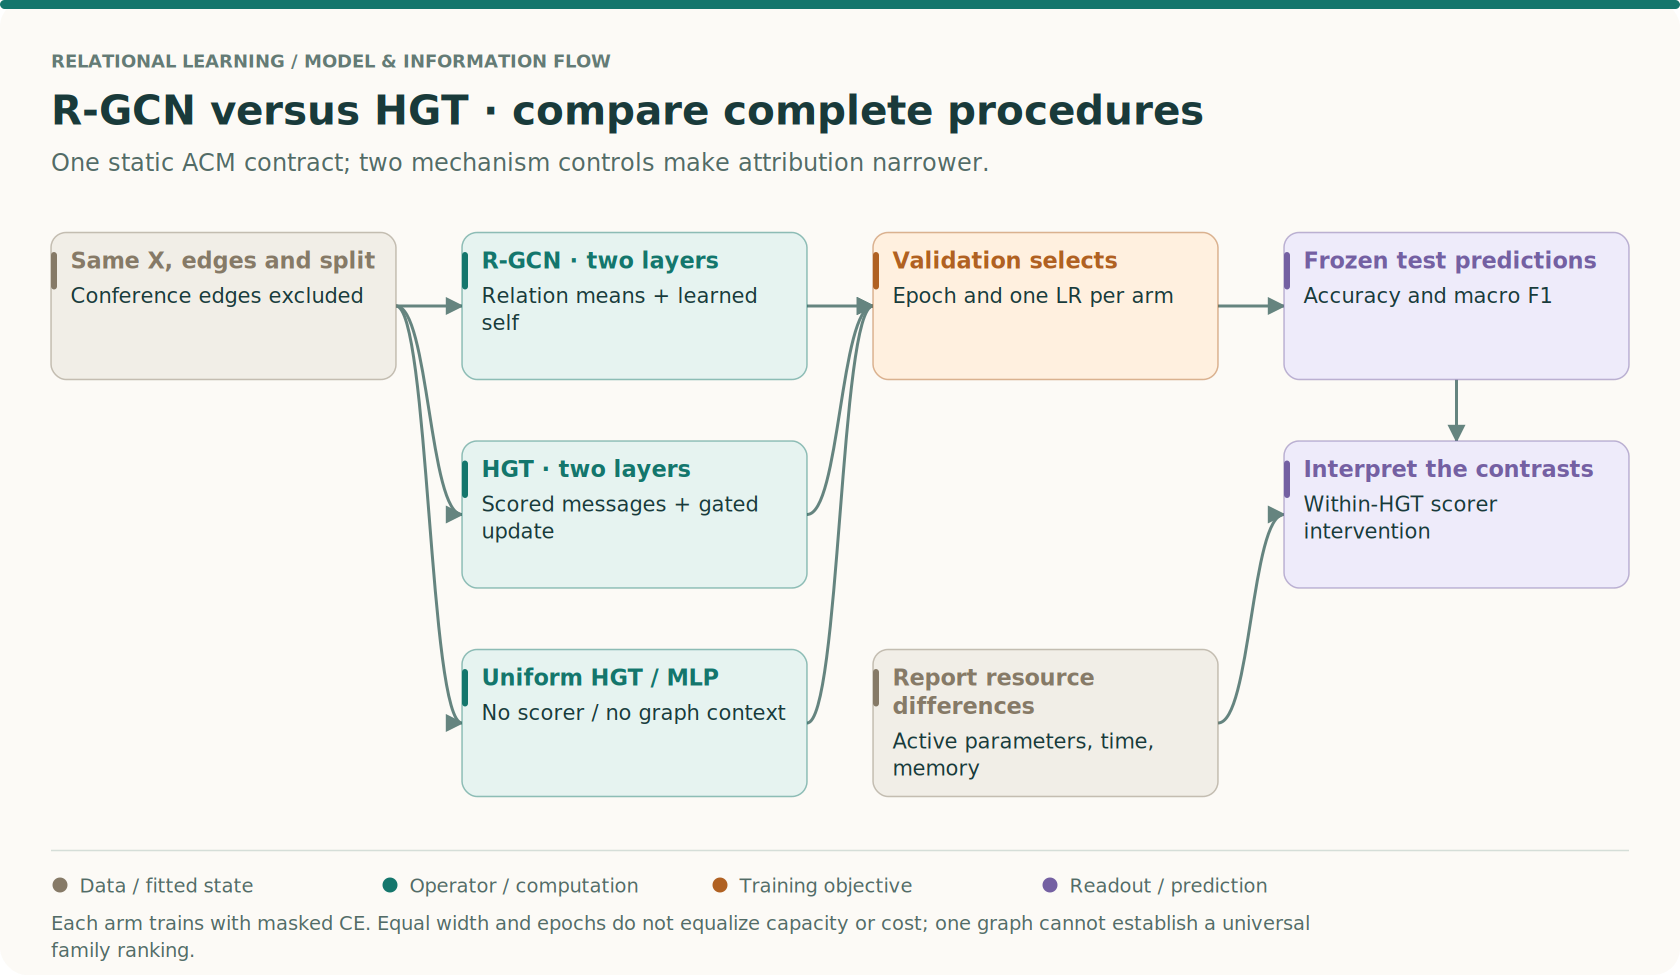</div><figcaption>One static ACM contract; two mechanism controls make attribution narrower. Each arm trains with masked CE. Equal width and epochs do not equalize capacity or cost; one graph cannot establish a universal family ranking.</figcaption></figure>

### Name the contrast before reading the score

“Does HGT beat R-GCN under this recipe?” compares two complete systems. They differ in normalizers, transformations, nonlinearities, residuals, normalization layers and parameter counts. “Does the learned scorer help within this HGT design?” is narrower: compare HGT with the declared uniform-HGT control. The MLP asks a different question again: what can the paper's own words predict without graph context?

These controls do not provide perfect causal identification of an abstract mechanism. Training trajectories adapt after the intervention. They do, however, specify what was changed more precisely than a comparison of names. Read [R-GCN Eq. 2](https://arxiv.org/html/1703.06103v4) and [HGT §3](https://arxiv.org/html/2003.01332v1) beside the concrete course operators, including their declared release differences.

### Follow the same target through four routes

Every arm starts with the same paper identity and feature row. The MLP processes that row alone. The graph encoders also use author and subject connections. In two layers, another paper can influence the target through a shared author: first paper→author, then author→paper. This is the concrete additional information that a graph model may exploit under this static transductive contract.

Conference links would directly reveal the target class and are excluded. Subject links are included as declared context; their predictive strength must still be interpreted in the context of the task. A high score does not demonstrate that all relational domains have equally informative available neighbors. This is where the earlier baseline lessons remain relevant: a relational claim needs a credible flat-table comparator and an honest information-access statement.

### Separate normalization from attention

Take two author messages 2 and 8, plus one subject message −4, ignoring learned transforms and self terms. R-GCN's sum of relation means is 1. Uniform HGT's global incoming mean is 2. Attention weights proportional to `[1,3,2]` give 3. These are different operators before fitting anything.

Now duplicate **all** author messages, keeping the subject once. R-GCN still gives 1. Uniform HGT becomes `(2+8+2+8−4)/5=3.2`. If copied author edges retain their original logits, attention's numerator becomes `2+24+2+24−8=44`, denominator `1+3+1+3+2=10`, and the result becomes 4.4. Duplicating one relation changes its total competitive mass under cross-relation softmax. This is a diagnostic multigraph calculation, not a claim that the released ACM graph contains duplicate edges.

### Selection is itself part of the learning procedure

An epoch is selected using validation loss; a learning rate is selected using the declared aggregation across seeds. Only then are test predictions scored. Taking the maximum test score over epochs or rates would create a new procedure with test-label access. More search can help an arm even when its architecture stays fixed, so matching two tested rates is an explicit budget choice rather than a universal fairness guarantee.

<details><summary>Try first: if HGT beats R-GCN but ties uniform HGT, what can you conclude?</summary><p>The complete HGT procedure may help under this protocol, but the contrast does not isolate a benefit from learned attention scoring. Other retained components or optimization effects remain possible explanations. A point-estimate tie is also not proof of equivalence; report the paired results and uncertainty.</p></details>

**Bridge to L100.** Keep one graph as one statistical dataset, regardless of the number of seeds. The next checkpoint adds sampled context, target-order control and mini-batch optimization. Predict which conclusions would survive that change and which require a new run. The existing evidence and reproduction ledger below remain the authority for what was actually executed.

<!-- depth-walkthrough:end -->



## 2 · Define the comparison before choosing a winner

The previous lessons established that both families can pass messages on typed graphs. They did not establish that an HGT gain is *caused by attention*: HGT also changes projections, parameter counts, residual paths, nonlinearities and normalization. Comparing two complete systems changes all of these together.

Our central question is narrower: **under one declared data and training budget, how do these implemented families compare, and what changes when we remove HGT's content-dependent edge weights?** A family comparison answers the first part. A within-HGT intervention gives evidence about the second.

| Comparison | What changes | What a result can support |
|---|---|---|
| HGT versus R-GCN | Whole hidden operator, capacity and compute | Conditional family performance under this protocol |
| HGT versus uniform HGT | Learned scoring is removed; shared message/residual parameters remain | Value of the learned scoring mechanism including its capacity and optimization effects |
| Graph models versus MLP | Neighborhood access and graph operators | Whether this fitted graph pipeline improves over the feature-only baseline |
| Same model, another LR | Optimization trajectory | Sensitivity to the declared tuning budget |

None isolates a universal architectural truth. Even the attention ablation removes parameters and changes optimization. “Attention alone caused every point of gain” would still be too strong.



## 3 · One graph and one information contract

We download and SHA256-check the complete released `ACM.mat`, select the five conferences used by the DGL ACM raw example, and retain **all 4,025 selected papers, 7,167 connected authors and 60 connected subjects**. Compact auxiliary IDs preserve their original IDs in the evidence. This is **not** L092's 3,025-paper pickle or its historical split.

| Object | Representation | Use |
|---|---|---|
| Paper | 1,903 bag-of-words columns, normalized by each row's sum | Same inputs for all four arms |
| Author / subject | One constant feature equal to 1 | Learn typed starting states; no target-derived features |
| Paper ↔ author | 13,407 edges in each direction | Two-hop coauthor information |
| Paper ↔ subject | 4,025 edges in each direction | Two-hop subject context |
| Conference | Maps papers to three class labels | **Excluded from graph edges and input features** |
| Split | Seed 99; class-stratified 20% / 10% / remainder | 804 train / 403 validation / 2,818 test papers |

There is one subject incidence per selected paper. A subject can connect many papers: inspect degree before interpreting its influence. Subjects are a legitimate declared input in this static experiment; their relationship to venue categories can make this task easy. They do not establish useful deployment-time availability in a future temporal task.

**Transductive access is explicit.** Every selected paper's text and graph position are visible during training. Only 804 labels enter the training loss. Validation labels choose epochs and learning rates. Test labels enter final scoring after selection. Row normalization needs no corpus fitting; no labels create author or subject features. [L096's typed identity contract](https://avistian.github.io/relational/lessons/0096-multi-relational-data.html) still applies.



## 4 · Model architecture: follow one paper to its prediction

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">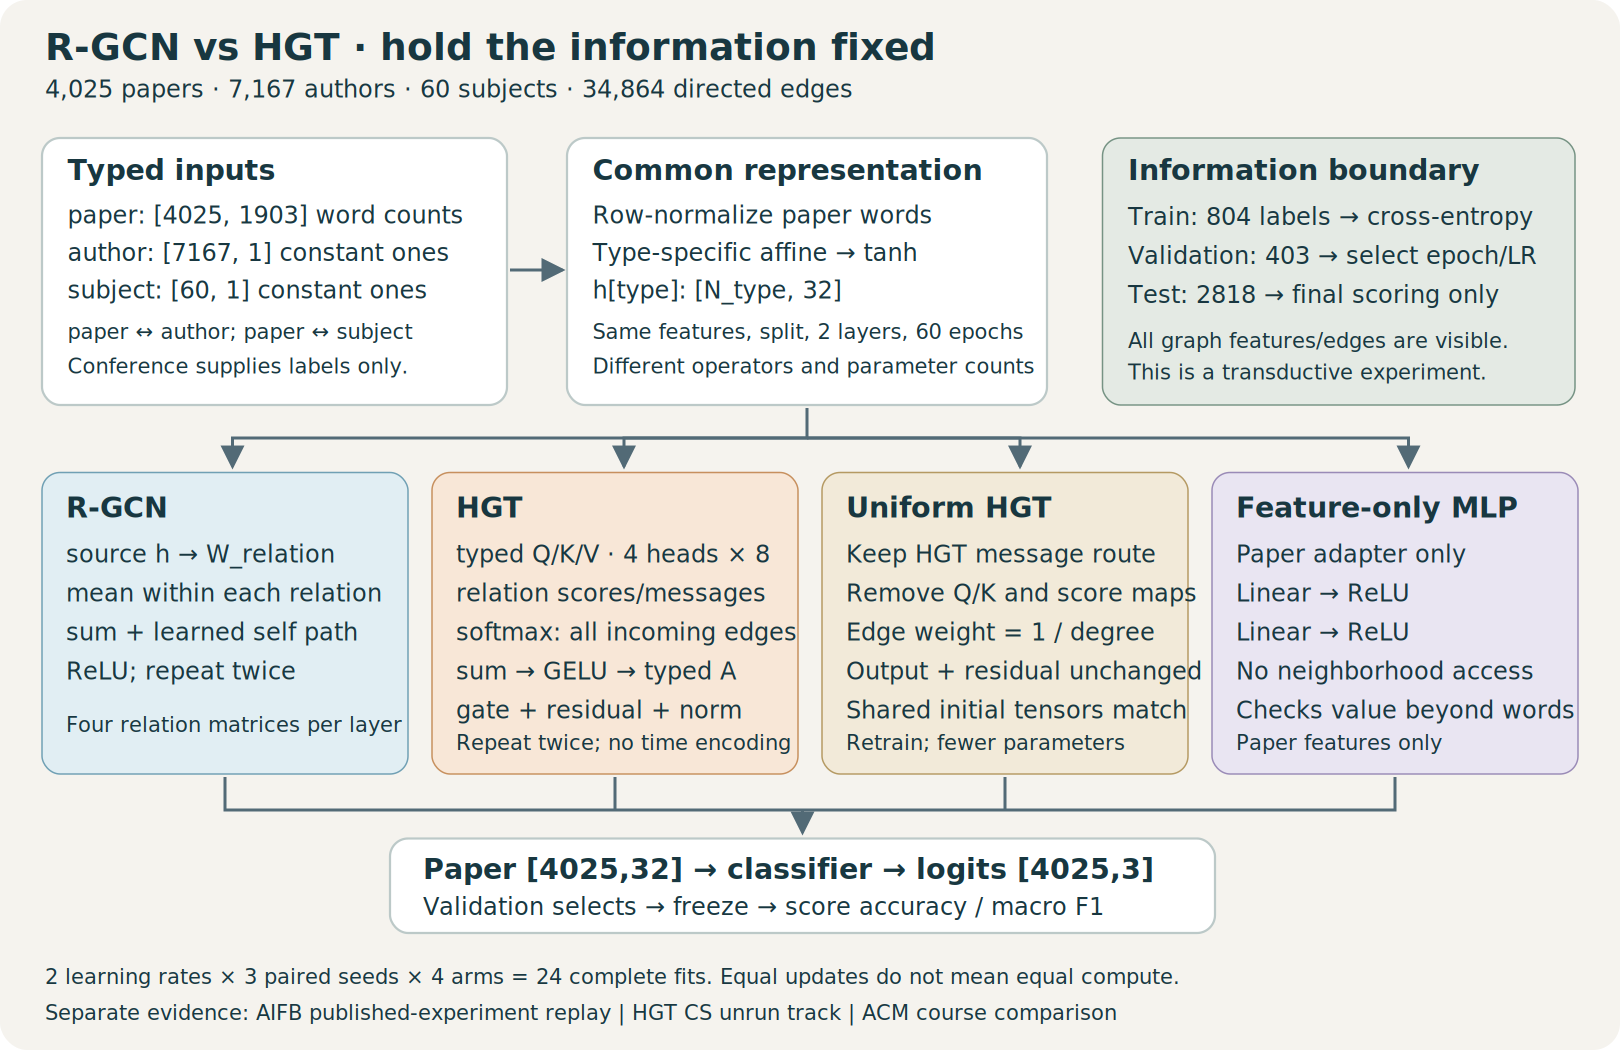</div><figcaption>Read left to right through the inputs, then down one branch to the prediction. Scroll horizontally on a narrow screen.</figcaption></figure>

Start with paper *p*. A type-specific affine adapter produces a 32-dimensional state followed by `tanh`. Authors and subjects have their own adapters. At layer one, an author receives information from that author's papers; at layer two, that author sends the resulting state back to *p*. This is how another paper's words can influence *p* through a shared author. The subject route works similarly. The MLP keeps only *p*'s words.

Every graph model has two layers, width 32 and the same four directed input stores. An affine classifier maps the final paper state to three logits. The loss uses only the train slice. Inference evaluates all paper states, then selects the test slice. There is no temporal encoding: this graph has no declared prediction-time interface. There is no neighborhood sampling: full-graph execution removes the sampler as a confound while [L098](https://avistian.github.io/relational/lessons/0098-hetero-mini-batching.html) explains how to reintroduce it carefully.

### Step A · R-GCN first decides which relation produced a message

For each relation *r*, transform source states with `W_r`, average the incoming messages of that relation, sum the relation means, add one learned self transform and apply ReLU. This is the local mean-normalized Eq. 2 operator. The course model uses unrestricted relation matrices, plus biased adapters/self transforms and a classifier; it is not the featureless AIFB model from L091.

```python
src, dst = edge
message = x_source[src] @ W_relation
aggregate = zeros_for_receivers.index_add(0, dst, message)
mean = aggregate / degree_for_this_relation.clamp_min(1)[:, None]
# Sum one such mean per relation; then add the self path and apply ReLU.
```

The implementation computes the source transform once before indexing edges. Linearity makes this equivalent. An isolated receiver gets a zero neighbor contribution, so its self path remains meaningful. Basis decomposition from Eq. 3 is unnecessary for only four relations and is not introduced silently as another experimental variable.

### Step B · HGT lets the receiver help determine an edge weight

The receiver's type selects a query projection; the source's type selects key and value projections. Each width-32 state becomes four heads of dimension eight. Relation-specific matrices transform keys and values; a per-relation/head prior scales the query–key dot product. The implementation follows the [pinned modern pyHGT operator](https://github.com/acbull/pyHGT/blob/85eaccd482bc1d1af56c2de297b6e3a88b96d5cd/OAG/pyHGT/conv.py), with temporal encoding disabled.

```text
score(edge, head) = prior[r, head] * dot(Q_type(dst), K_type(src) @ A_r) / sqrt(8)
message(edge, head) = V_type(src) @ M_r
alpha = softmax(score over every incoming edge of this receiver and head)
aggregate = sum(alpha * message)
```

Concatenate the heads, apply GELU and a destination-type output projection, blend with the old state through a learned sigmoid gate, then LayerNorm. Those operations matter: **R-GCN versus HGT changes much more than a softmax.** The lesson's independent check compares outputs and gradients against L093's archived modern-release port. That establishes operator agreement, not historical training-result reproduction.

### Step C · Remove the scorer without changing the rest of HGT

Uniform HGT deletes Q/K projections, attention matrices and score priors. Every incoming edge receives `1 / total_in_degree`. Value projections, relation message matrices, output projections, residual gates and LayerNorm remain. Every parameter shared with HGT starts with exactly the same tensor for a paired seed. Both models are then trained independently.

R-GCN divides by **relation-specific** degree and sums relation means. Uniform HGT divides by **total** degree. They are different even before considering transforms or residuals. Removing an attention scorer does not turn HGT into R-GCN.



## 5 · Worked trace: three messages, three answers

Freeze scalar messages to author A = 2, author B = 8, subject S = −4. Ignore transforms and self paths for this trace. Give attention logits `0, ln 3, ln 2`.

1. **R-GCN:** author mean `(2 + 8) / 2 = 5`; subject mean `−4`; their sum is **1**.
2. **Uniform HGT:** one mean over all three messages: `(2 + 8 − 4) / 3 = 2`.
3. **Attention:** exponentials are `1, 3, 2`, total 6; weights are `1/6, 3/6, 2/6`; the weighted sum is **3**.

Before using the control, predict what happens when the subject score rises to `ln 8`. Then duplicate author A and explain whether either mean is invariant. Duplicating just one neighbor changes the empirical distribution; invariance to *all* neighbors being duplicated is a different claim.

**Portable intervention:** reproduce the three scalar aggregations in the worked-trace cell below.

**Predict first:** does replacing HGT attention with uniform weights make it R-GCN? Defend your answer using the trace.



## 6 · Freeze the training and selection protocol

We run **24 fits: four arms × two learning rates × three seeds**, each for all 60 epochs. Learning rates are .003 and .01; Adam uses weight decay .001; dropout is zero; width is 32; depth is two. HGT uses four heads. Full-graph CPU execution uses two threads and deterministic algorithms. Every arm gets both learning rates and all three seeds. No early stopping shortens an arm's update budget.

At each epoch, save a checkpoint only if validation cross-entropy strictly improves. Ties keep the earliest epoch. After all fits, choose one learning rate per arm by mean best validation CE across the three seeds; a tie chooses the smaller rate. Only then restore selected checkpoints and evaluate test accuracy and macro F1. Seeds do not get their own test-selected learning rates.

The MLP allocates a paper adapter, two ReLU layers and a classifier. It has no unused auxiliary adapters. Graph models may still have allocated parameters that do not participate in the two-layer paper-only supervised path; the evidence reports both **allocated** and **active** counts. “Active” means autograd reaches the parameter, not that every entry has a nonzero derivative or that all parameters are statistically identifiable.

Equal width and updates do **not** match parameter count, runtime, memory or FLOPs. We report those differences instead of hiding them behind “fair.” Matching parameters or wall-clock budget would answer a different question and requires a separately frozen follow-up. The two-LR search is intentionally modest; weak optimization in one family is a limit on the conclusion.



## 7 · Read the measured evidence before writing the attribution

**Frozen author measurements: all 24 fits and all 1,440 epochs completed.** Accuracy SD is in percentage points, across three seeds. Runtime is measured CPU wall time for training, validation and final gradient audit; it is not a FLOP count or a separate timing benchmark.

| Arm | Selected LR | Test accuracy mean ± seed SD | Macro F1 mean | Parameters allocated / active | Seconds per selected fit |
|---|---:|---:|---:|---:|---:|
| rgcn | 0.01 | 55.24% ± 9.75 pp | 0.3240 | 71,459 / 71,459 | 3.60 |
| hgt | 0.003 | 87.09% ± 1.01 pp | 0.8694 | 91,017 / 84,553 | 13.55 |
| hgt_uniform | 0.003 | 87.86% ± 0.97 pp | 0.8787 | 76,265 / 72,969 | 7.98 |
| mlp | 0.01 | 68.06% ± 1.55 pp | 0.5469 | 63,139 / 63,139 | 1.45 |

| Paired seed | HGT − R-GCN | HGT − uniform HGT | HGT − MLP |
|---|---:|---:|---:|
| 0 | +19.91 pp | -0.57 pp | +18.45 pp |
| 1 | +38.64 pp | -0.64 pp | +21.68 pp |
| 2 | +37.01 pp | -1.10 pp | +16.96 pp |

**Observed attribution:** uniform HGT has the higher mean here. The HGT family gap over this R-GCN configuration does not establish a benefit from learned attention. The R-GCN and MLP curves reveal substantial optimization limitations within the fixed 60-epoch budget. No universal family ranking follows.


Read each seed pair before the mean. The differences are paired by declared seed and shared split; architecture-specific parameters are not magically identical. A sample SD across three seeds describes optimization variability on **one fixed graph and split**. It is not uncertainty across datasets, and 2,818 test papers are not 2,818 independent graph experiments.

**Sanity checks:** if the MLP is competitive, paper text already carries useful signal. If uniform HGT is competitive with HGT, do not claim adaptive scoring is required. If R-GCN's validation curve remains high at epoch 60, this protocol has not demonstrated its best achievable performance. Inspect both learning rates, selection epochs and loss traces before making a mechanism claim.

Your attribution table must contain an observation, the actual intervention, an alternative explanation and the narrowest justified conclusion. Example: “HGT outperformed this R-GCN configuration under the fixed budget; attention, residuals, normalization and optimization all changed; a within-HGT ablation is needed before crediting scoring.” Replace the observation with the measured values, including any result that contradicts your prediction.



## 8 · Full reproduction: three explicit evidence scopes

“Full” needs a target. This lesson's full **course experiment** means every one of the declared 24 fits, all epochs, frozen selection, saved checkpoints, raw predictions and an independent metric audit. It does not mean reproducing either paper's complete benchmark collection.

| Scope | Named target | Evidence boundary |
|---|---|---|
| ACM controlled comparison | The complete protocol in section 6 | New course experiment; no published score assigned |
| R-GCN published experiment | Schlichtkrull Table 2, AIFB, ten runs | Fresh complete release-protocol port; exact historical backend/RNG identity remains INCOMPARABLE |
| HGT published experiment | Hu Table 2, CS Paper–Field L2, five HGT trainings | Runnable full-setting port; execution NOT_RUN; source/protocol gaps remain |

The AIFB replay is separate: 50 updates per run, original 140/36 split, featureless inputs, width16 and unrestricted relation weights. The fresh mean is **95.8333%**, sample SD **1.4640 percentage points**. Agreement with the printed mean does not recover unknown historical seeds, original node ordering or Keras/Theano arithmetic. See the [fresh raw result](https://avistian.github.io/relational/labs/_paper_l099_aifb_results.json) and [L091 protocol audit](https://avistian.github.io/relational/labs/l091-reproduction.md).

The HGT CS archive is already available locally, but L093 recorded a decoding MemoryError under a 10 GiB address-space guard and a GPU-account execution rejection. Those are **prior observations**, not a new capacity test in L099. This lesson does not reclassify the smaller NN run or ACM run as CS. The full CS launcher preserves five seeds, full schedule and CS hash, and also offers the course R-GCN comparator. That extra comparator is not an exact reconstruction of the paper's R-GCN baseline. The [L093 protocol ledger](https://avistian.github.io/relational/labs/l093-reproduction.md) explains modern/publication-era source differences. Full-paper parity remains **NOT_ESTABLISHED**.

From the repository root:

```bash
.venv/bin/python labs/_verify_l099.py
.venv/bin/python labs/_run_l099.py
.venv/bin/python labs/_audit_l099.py
.venv/bin/python labs/_paper_l099.py --target aifb
# Full CS lane requires the hash-verified graph and sufficient host/device resources:
.venv/bin/python labs/_paper_l099.py --target hgt-cs --device cuda
```

The standalone solution reruns all 24 course fits outside the repository with inline loader/model/trainer code and freshly downloaded, verified data bytes. The execution harness uses bounded curl for the download after an initial urllib connection stalled. Browser checks, notebook execution, a clean dependency install, live Colab and deployment are separate claims. Consult the [execution](https://avistian.github.io/relational/labs/_execution_l099_results.json) and [delivery](https://avistian.github.io/relational/labs/_delivery_l099_results.json) records. Running code is not a substitute for your written defense.



## 9 · Lab: predict → implement → check → defend

Implement three live tasks in the student notebook:

1. `relation_mean`: hand-check two receivers and an isolated row; verify source gradients of 1/2, 1/2 and 1.
2. `receiver_softmax`: normalize over incoming edges across relations and heads; check stable scores, empty edges and gradient agreement with a dense oracle.
3. `choose_config`: choose by mean validation CE, not by best test score, best single seed or last epoch.

Then execute all fits, save `l099-fresh.json`, inspect your selected rates and compare per-seed predictions with the frozen author references. Runtime can vary; do not require byte equality for timing fields or serialized checkpoint files. Numerical agreement under the recorded environment is stronger than an unexplained matching aggregate.

**EXIT — PENDING_WRITTEN_DEFENSE:** submit the three implementations, fresh result file and your attribution table. Explain (a) why conference edges are forbidden, (b) why uniform HGT differs from R-GCN, (c) what is and is not held fixed, (d) why validation-only selection matters, (e) why neither ACM nor a matching AIFB mean proves full HGT reproduction. Propose one follow-up with a frozen budget that could overturn your preferred explanation.

**Teach back:** distinguish a family comparison from a within-family intervention and state one remaining confound.

Ask the agent follow-up questions about any equation, tensor, experiment record or uncertainty. Return tomorrow to reconstruct the three-message example from memory. Then use [L100's checkpoint specification](https://avistian.github.io/relational/plan/year-3.md) to defend a graph with at least three node types and a controlled architecture comparison.


## Visible implementation

All data, operators, training, selection and scoring are inline. Complete the three TODO functions. The full suite does fresh computation; frozen author measurements are references only.

In [2]:
import copy, hashlib, json, math, platform, time, urllib.request

from pathlib import Path

import numpy as np

import scipy.io as sio

import torch

from torch import nn

from torch.nn import functional as F

ROUTES = [(0,1),(1,0),(0,2),(2,0)]

ARMS = ['rgcn','hgt','hgt_uniform','mlp']

DATA_URL = 'https://data.dgl.ai/dataset/ACM.mat'

DATA_SHA256 = '0ccd838e545e8f16e3dc84356da2f51dfd2290c32e37a784e374dd510c76578d'

LEARNING_RATES = [.003,.01]

SEEDS = [0,1,2]

EPOCHS = 60

### TODO · relation_mean

TODO 1: mean incoming source rows per receiver; empty neighborhoods return zero.

In [3]:
def relation_mean(x, edge, receivers):
    """TODO 1: mean incoming source rows per receiver; empty neighborhoods return zero."""
    src,dst=edge
    out=x.new_zeros((receivers,x.shape[1])).index_add(0,dst,x[src])
    degree=torch.bincount(dst,minlength=receivers).clamp_min(1)
    return out/degree[:,None]

### CHECK · relation_mean

In [4]:
x=torch.tensor([[2.],[8.],[-4.]],requires_grad=True)
e=torch.tensor([[0,1,2],[0,0,1]])
y=relation_mean(x,e,3)
assert torch.equal(y,torch.tensor([[5.],[-4.],[0.]]))
y.sum().backward();assert torch.equal(x.grad,torch.tensor([[.5],[.5],[1.]]))
assert relation_mean(x,torch.empty((2,0),dtype=torch.long),0).shape==(0,1)
print('PASS: means, isolated receiver, empty relation, source gradients')

PASS: means, isolated receiver, empty relation, source gradients


### TODO · receiver_softmax

TODO 2: stable E×heads softmax over ALL incoming relations per receiver/head.

In [5]:
def receiver_softmax(scores, dst, receivers):
    """TODO 2: stable E×heads softmax over ALL incoming relations per receiver/head."""
    ix=dst[:,None].expand_as(scores)
    maximum=scores.new_full((receivers,scores.shape[1]),-torch.inf)
    maximum.scatter_reduce_(0,ix,scores.detach(),reduce='amax',include_self=True)
    weights=(scores-maximum[dst]).exp()
    denominator=scores.new_zeros(maximum.shape).scatter_add(0,ix,weights)
    return weights/denominator[dst].clamp_min(torch.finfo(scores.dtype).tiny)

### CHECK · receiver_softmax

In [6]:
s=torch.tensor([[1000.,1.],[1000.,2.],[2.,3.]],dtype=torch.double,requires_grad=True)
dst=torch.tensor([0,0,2]);a=receiver_softmax(s,dst,4)
reference=torch.cat([s[:2].softmax(0),torch.ones_like(s[2:])])
assert torch.allclose(a,reference)
ga=torch.autograd.grad(a.square().sum(),s,retain_graph=True)[0]
gb=torch.autograd.grad(reference.square().sum(),s)[0]
assert torch.allclose(ga,gb)
assert receiver_softmax(s[:0],dst[:0],4).shape==(0,2)
print('PASS: joint receiver normalization, stable scores, gradients, empty edges')

PASS: joint receiver normalization, stable scores, gradients, empty edges


### TODO · choose_config

TODO 3: minimize mean best validation CE across seeds; ties use smaller LR.

In [7]:
def choose_config(records, arm):
    """TODO 3: minimize mean best validation CE across seeds; ties use smaller LR."""
    rates=sorted({r['lr'] for r in records if r['arm']==arm})
    return min(rates,key=lambda lr:(np.mean([r['best_val_ce'] for r in records if r['arm']==arm and r['lr']==lr]),lr))

### CHECK · choose_config

In [8]:
records=[{'arm':'hgt','lr':lr,'seed':seed,'best_val_ce':loss,'test_accuracy':test} for lr,seed,loss,test in [(.01,0,.4,.99),(.01,1,.1,.99),(.003,0,.2,.01),(.003,1,.2,.01)]]
assert choose_config(records,'hgt')==.003
for r in records:r['test_accuracy']=1-r['test_accuracy']
assert choose_config(records,'hgt')==.003
print('PASS: mean validation beats best-seed and test-score temptations')

PASS: mean validation beats best-seed and test-score temptations


### PROVIDED · load_graph

Full DGL ACM conference-filtered graph; fixed course split; no conference edges.

In [9]:
def load_graph(root):
    """Full DGL ACM conference-filtered graph; fixed course split; no conference edges."""
    root=Path(root);root.mkdir(parents=True,exist_ok=True);path=root/'ACM.mat'
    if not path.exists():
        with urllib.request.urlopen(DATA_URL,timeout=120) as r:payload=r.read()
        if hashlib.sha256(payload).hexdigest()!=DATA_SHA256:raise ValueError('Download hash mismatch')
        path.write_bytes(payload)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=DATA_SHA256:raise ValueError('Dataset hash mismatch')
    raw=sio.loadmat(path,spmatrix=True)
    conf_ids=[0,1,9,10,13];label_ids=[0,1,2,2,1]
    ids=np.flatnonzero(np.asarray(raw['PvsC'][:,conf_ids].sum(1)).ravel())
    conference=raw['PvsC'][ids].toarray().argmax(1)
    labels=np.array([dict(zip(conf_ids,label_ids))[c] for c in conference])
    features=raw['PvsT'][ids].toarray().astype('float32')
    features/=np.maximum(features.sum(1,keepdims=True),1)
    xs=[torch.from_numpy(features)];edges=[];node_ids=[ids.tolist()]
    for key in ['PvsA','PvsL']:
        incidence=raw[key][ids].tocsr();connected=np.flatnonzero(np.asarray(incidence.sum(0)).ravel())
        incidence=incidence[:,connected];a,b=incidence.nonzero()
        edge=torch.tensor(np.stack([a,b]),dtype=torch.long)
        edges.extend([edge,edge.flip(0)]);xs.append(torch.ones((len(connected),1)));node_ids.append(connected.tolist())
    rng=np.random.RandomState(99);parts=[[],[],[]]
    for c in range(3):
        perm=rng.permutation(np.flatnonzero(labels==c));n=len(perm);a=int(.2*n);b=int(.3*n)
        for acc,subset in zip(parts,[perm[:a],perm[a:b],perm[b:]]):acc.extend(subset.tolist())
    parts=[torch.tensor(sorted(v),dtype=torch.long) for v in parts]
    assert len(ids)==4025 and [len(t) for t in xs]==[4025,7167,60]
    assert len(torch.unique(torch.cat(parts)))==len(ids)
    assert [e.shape[1] for e in edges]==[13407,13407,4025,4025]
    meta={'data_url':DATA_URL,'data_sha256':DATA_SHA256,'nodes':[len(t) for t in xs],
          'features':[t.shape[1] for t in xs],'directed_edges':[e.shape[1] for e in edges],
          'raw_node_ids':node_ids,'split_seed':99,'split_sizes':[len(p) for p in parts],
          'split_sha256':hashlib.sha256(b''.join(p.numpy().tobytes() for p in parts)).hexdigest(),
          'graph_sha256':hashlib.sha256(b''.join(e.numpy().tobytes() for e in edges)).hexdigest(),
          'access':'transductive; all selected paper features/edges; labels only in masked objective/validation/scoring',
          'forbidden_input':'PvsC: conference incidence supplies labels only, never edges/features'}
    return {'x':xs,'edges':edges,'y':torch.tensor(labels),'train':parts[0],'val':parts[1],'test':parts[2],'meta':meta}

### PROVIDED · RGCNLayer

Eq2 relation-wise mean, sum over relations, one learned self transform, ReLU.

In [10]:
class RGCNLayer(nn.Module):
    """Eq2 relation-wise mean, sum over relations, one learned self transform, ReLU."""
    def __init__(self,width):
        super().__init__();self.weights=nn.Parameter(torch.empty(4,width,width));self.self_linear=nn.Linear(width,width)
        for w in self.weights:nn.init.xavier_uniform_(w)
    def forward(self,x,edges):
        out=[self.self_linear(t) for t in x]
        for r,(source,target) in enumerate(ROUTES):
            out[target]=out[target]+relation_mean(x[source]@self.weights[r],edges[r],len(x[target]))
        return [z.relu() for z in out]

### PROVIDED · HGTLayer

Typed multi-head attention with cross-relation normalization and gated residual.
uniform=True removes Q/K, relation attention matrices and priors, retaining V,
relation message matrices, A, skip and LayerNorm. No temporal encoding on ACM.

In [11]:
class HGTLayer(nn.Module):
    """Typed multi-head attention with cross-relation normalization and gated residual.
    uniform=True removes Q/K, relation attention matrices and priors, retaining V,
    relation message matrices, A, skip and LayerNorm. No temporal encoding on ACM.
    """
    def __init__(self,width,heads=4,uniform=False):
        super().__init__();self.width=width;self.heads=heads;self.d=width//heads;self.uniform=uniform
        if width%heads:raise ValueError('width must be divisible by heads')
        if not uniform:
            self.k_linears=nn.ModuleList([nn.Linear(width,width) for _ in range(3)])
            self.q_linears=nn.ModuleList([nn.Linear(width,width) for _ in range(3)])
        self.v_linears=nn.ModuleList([nn.Linear(width,width) for _ in range(3)])
        self.a_linears=nn.ModuleList([nn.Linear(width,width) for _ in range(3)])
        self.norms=nn.ModuleList([nn.LayerNorm(width) for _ in range(3)])
        if not uniform:
            self.relation_pri=nn.Parameter(torch.ones(4,heads))
            self.relation_att=nn.Parameter(torch.empty(4,heads,self.d,self.d))
        self.relation_msg=nn.Parameter(torch.empty(4,heads,self.d,self.d));self.skip=nn.Parameter(torch.ones(3))
        if not uniform:nn.init.uniform_(self.relation_att,-math.sqrt(3/self.d),math.sqrt(3/self.d))
        nn.init.uniform_(self.relation_msg,-math.sqrt(3/self.d),math.sqrt(3/self.d))
    def forward(self,x,edges):
        values=[f(z).view(-1,self.heads,self.d) for f,z in zip(self.v_linears,x)]
        if not self.uniform:
            keys=[f(z).view(-1,self.heads,self.d) for f,z in zip(self.k_linears,x)]
            queries=[f(z).view(-1,self.heads,self.d) for f,z in zip(self.q_linears,x)]
        messages=[[],[],[]];scores=[[],[],[]];receivers=[[],[],[]]
        for r,(s,t) in enumerate(ROUTES):
            src,dst=edges[r]
            msg=torch.einsum('ehd,hdf->ehf',values[s][src],self.relation_msg[r])
            if self.uniform:score=msg.new_zeros((len(src),self.heads))
            else:
                key=torch.einsum('ehd,hdf->ehf',keys[s][src],self.relation_att[r])
                score=(queries[t][dst]*key).sum(-1)*self.relation_pri[r]/math.sqrt(self.d)
            messages[t].append(msg);scores[t].append(score);receivers[t].append(dst)
        out=[]
        for t in range(3):
            dst=torch.cat(receivers[t]);alpha=receiver_softmax(torch.cat(scores[t]),dst,len(x[t]))
            weighted=(torch.cat(messages[t])*alpha[:,:,None]).reshape(-1,self.width)
            aggregate=x[t].new_zeros(x[t].shape).index_add(0,dst,weighted)
            a=self.skip[t].sigmoid();out.append(self.norms[t](a*self.a_linears[t](F.gelu(aggregate))+(1-a)*x[t]))
        return out

### PROVIDED · Model

Same width32, depth2, adapters and classifier; family-specific hidden operators.

In [12]:
class Model(nn.Module):
    """Same width32, depth2, adapters and classifier; family-specific hidden operators."""
    def __init__(self,inputs,arm,width=32):
        super().__init__();self.arm=arm
        if arm not in ARMS:raise ValueError(arm)
        self.adapters=nn.ModuleList([nn.Linear(d,width) for d in (inputs[:1] if arm=='mlp' else inputs)])
        if arm=='mlp':self.layers=nn.ModuleList([nn.Linear(width,width) for _ in range(2)])
        else:self.layers=nn.ModuleList([RGCNLayer(width) if arm=='rgcn' else HGTLayer(width,uniform=arm=='hgt_uniform') for _ in range(2)])
        self.classifier=nn.Linear(width,3)
    def forward(self,g):
        x=[torch.tanh(f(t)) for f,t in zip(self.adapters,g['x'])]
        for layer in self.layers:x=[layer(x[0]).relu()] if self.arm=='mlp' else layer(x,g['edges'])
        return self.classifier(x[0])

### PROVIDED · fit

All epochs run. Strict validation-CE improvement saves earliest minimum; no test use.

In [13]:
def fit(g,arm,lr,seed,epochs=EPOCHS,width=32):
    """All epochs run. Strict validation-CE improvement saves earliest minimum; no test use."""
    torch.manual_seed(seed);model=Model([x.shape[1] for x in g['x']],arm,width)
    # Pair common initial tensors for the attention ablation, despite removed scorer draws.
    if arm=='hgt_uniform':
        torch.manual_seed(seed);reference=Model([x.shape[1] for x in g['x']],'hgt',width)
        state=reference.state_dict();model.load_state_dict({k:state[k] for k in model.state_dict()})
    optimizer=torch.optim.Adam(model.parameters(),lr=lr,weight_decay=.001)
    best=float('inf');checkpoint=None;trace=[];start=time.perf_counter()
    for epoch in range(epochs):
        model.train();optimizer.zero_grad();z=model(g);loss=F.cross_entropy(z[g['train']],g['y'][g['train']]);loss.backward();optimizer.step()
        model.eval()
        with torch.no_grad():v=float(F.cross_entropy(model(g)[g['val']],g['y'][g['val']]))
        trace.append({'epoch':epoch+1,'train_ce':float(loss.detach()),'val_ce':v})
        if v<best:best=v;selected_epoch=epoch+1;checkpoint=copy.deepcopy(model.state_dict())
    model.load_state_dict(checkpoint);model.eval()
    # Active means participates in the supervised graph; grad may numerically be zero.
    model.zero_grad();F.cross_entropy(model(g)[g['train']],g['y'][g['train']]).backward()
    active=sum(p.numel() for p in model.parameters() if p.grad is not None)
    record={'arm':arm,'lr':lr,'seed':seed,'epochs':epochs,'selected_epoch':selected_epoch,'best_val_ce':best,
            'parameters':sum(p.numel() for p in model.parameters()),'active_parameters':active,
            'seconds':time.perf_counter()-start,'trace':trace}
    return record,model

### PROVIDED · classification_metrics

Accuracy and macro F1; three fixed classes, zero undefined F1.

In [14]:
def classification_metrics(truth,prediction):
    """Accuracy and macro F1; three fixed classes, zero undefined F1."""
    truth=np.asarray(truth);prediction=np.asarray(prediction);f=[]
    for c in range(3):
        tp=np.sum((truth==c)&(prediction==c));fp=np.sum((truth!=c)&(prediction==c));fn=np.sum((truth==c)&(prediction!=c))
        f.append(float(2*tp/max(2*tp+fp+fn,1)))
    return {'accuracy':float(np.mean(truth==prediction)),'macro_f1':float(np.mean(f))}

### PROVIDED · run_suite

Entire preregistered 24-fit search, then one frozen selection and test phase.
Writes RUNNING checkpoints after each fit. No automatic resume or stale reuse.

In [15]:
def run_suite(root,output,progress=True):
    """Entire preregistered 24-fit search, then one frozen selection and test phase.
    Writes RUNNING checkpoints after each fit. No automatic resume or stale reuse.
    """
    torch.set_num_threads(2);torch.use_deterministic_algorithms(True)
    g=load_graph(root);output=Path(output);output.parent.mkdir(parents=True,exist_ok=True)
    checkpoint_dir=output.parent/(output.stem+'-checkpoints');checkpoint_dir.mkdir(exist_ok=True)
    result={'status':'RUNNING','protocol':{'arms':ARMS,'rates':LEARNING_RATES,'seeds':SEEDS,'epochs':EPOCHS,
        'width':32,'layers':2,'heads':4,'weight_decay':.001,'dropout':0,'split_seed':99,'selection':'mean best validation CE across seeds per arm; earliest minimum checkpoint','ablation_initialization':'HGT and uniform HGT share every common initial tensor'},
        'environment':{'python':platform.python_version(),'torch':torch.__version__,'numpy':np.__version__,'platform':platform.platform(),'threads':2},
        'data':g['meta'],'splits':{k:g[k].tolist() for k in ['train','val','test']},'runs':[],
        'paper_parity':'NOT_ESTABLISHED','scope':'full declared course experiment, not a historical paper experiment'}
    def save():output.write_text(json.dumps(result,indent=2)+'\n')
    save()
    for arm in ARMS:
        for lr in LEARNING_RATES:
            for seed in SEEDS:
                rec,model=fit(g,arm,lr,seed)
                name=f'{arm}-{lr}-{seed}.pt';path=checkpoint_dir/name;torch.save(model.state_dict(),path)
                rec['checkpoint_file']=name;rec['checkpoint_sha256']=hashlib.sha256(path.read_bytes()).hexdigest()
                result['runs'].append(rec);save()
                if progress:print(len(result['runs']),'/24',arm,lr,seed,'val',round(rec['best_val_ce'],4),'seconds',round(rec['seconds'],1),flush=True)
    result['selected_rates']={arm:choose_config(result['runs'],arm) for arm in ARMS}
    result['selected']=[]
    for rec in result['runs']:
        if rec['lr']!=result['selected_rates'][rec['arm']]:continue
        model=Model([x.shape[1] for x in g['x']],rec['arm'])
        model.load_state_dict(torch.load(checkpoint_dir/rec['checkpoint_file'],weights_only=True));model.eval()
        with torch.no_grad():pred=model(g)[g['test']].argmax(1).tolist()
        row={k:rec[k] for k in ['arm','lr','seed','selected_epoch','parameters','active_parameters','seconds']}
        row.update(classification_metrics(g['y'][g['test']].tolist(),pred));row['test_predictions']=pred;result['selected'].append(row)
    result['test_labels']=g['y'][g['test']].tolist()
    result['summary']={arm:{key:{'mean':float(np.mean(v:=[r[key] for r in result['selected'] if r['arm']==arm])),
                  'sample_sd':float(np.std(v,ddof=1))} for key in ['accuracy','macro_f1','seconds']} for arm in ARMS}
    result['paired_accuracy_differences']={other:[next(r['accuracy'] for r in result['selected'] if r['arm']=='hgt' and r['seed']==seed)-next(r['accuracy'] for r in result['selected'] if r['arm']==other and r['seed']==seed) for seed in SEEDS] for other in ['rgcn','hgt_uniform','mlp']}
    result['status']='COMPLETE';save();return result

## Worked trace: predict before execution

Explain why changing the last score or duplicating one edge changes the output. This scalar trace is not a fitted-model comparison.

In [16]:
messages=torch.tensor([2.,8.,-4.]);scores=torch.tensor([0.,math.log(3),math.log(2)])
rgcn=(2+8)/2-4;uniform=messages.mean();hgt=(scores.softmax(0)*messages).sum()
assert rgcn==1 and uniform==2 and torch.allclose(hgt,torch.tensor(3.))
print('R-GCN:',rgcn,'Uniform:',uniform.item(),'Attention:',hgt.item())

R-GCN: 1.0 Uniform: 2.0 Attention: 3.000000476837158


## Full fresh experiment

Every fit runs all 60 epochs. The split, rates and seeds were frozen before test scoring. No cached scores are substituted. Preserve l099-fresh.json and its checkpoint folder.

In [17]:
fresh=run_suite('l099-data','l099-fresh.json')
assert fresh['status']=='COMPLETE' and len(fresh['runs'])==24
print('Selected learning rates:',fresh['selected_rates'])
print(json.dumps(fresh['summary'],indent=2))
AUTHOR_ACCURACY={'rgcn': 0.5524012301868938, 'hgt': 0.8709486633546252, 'hgt_uniform': 0.8786373314407382, 'mlp': 0.680624556422995}
print('Mean accuracy gaps from frozen author reference:',{a:fresh['summary'][a]['accuracy']['mean']-AUTHOR_ACCURACY[a] for a in ARMS})
print('Paired HGT differences:',fresh['paired_accuracy_differences'])

1 /24 rgcn 0.003 0 val 1.0344 seconds 3.6


2 /24 rgcn 0.003 1 val 1.0398 seconds 3.6


3 /24 rgcn 0.003 2 val 1.0405 seconds 3.5


4 /24 rgcn 0.01 0 val 0.8427 seconds 3.6


5 /24 rgcn 0.01 1 val 1.0337 seconds 3.5


...

21 /24 mlp 0.003 2 val 0.9974 seconds 1.4


22 /24 mlp 0.01 0 val 0.6757 seconds 1.4


23 /24 mlp 0.01 1 val 0.7024 seconds 1.4


24 /24 mlp 0.01 2 val 0.6492 seconds 1.4


Selected learning rates: {'rgcn': 0.01, 'hgt': 0.003, 'hgt_uniform': 0.003, 'mlp': 0.01}
{
  "rgcn": {
    "accuracy": {
      "mean": 0.5524012301868938,
      "sample_sd": 0.09752261466794244
    },
    "macro_f1": {
      "mean": 0.32402616130025647,
      "sample_sd": 0.17354333432218147
    },
    "seconds": {
      "mean": 3.5292892236666376,
      "sample_sd": 0.02215124983857431
    }
  },
  "hgt": {
    "accuracy": {
      "mean": 0.8709486633546252,
      "sample_sd": 0.01009538126016178
    },
    "macro_f1": {
      "mean": 0.869369553312099,
      "sample_sd": 0.009285976551080852
    },
    "seconds": {
      "mean": 13.170366001333301,
      "sample_sd": 0.16413794370096857
    }
  },
  "hgt_uniform": {
    "accuracy": {
      "mean": 0.8786373314407382,
      "sample_sd": 0.00965979956622865
    },
    "macro_f1": {
      "mean": 0.8787197491171508,
      "sample_sd": 0.010425520970139957
    },
    "seconds": {
      "mean": 7.896684623666563,
      "sample_sd": 0.0208

## EXIT · PENDING_WRITTEN_DEFENSE

Submit your three functions, l099-fresh.json and an attribution table (observation / intervention / alternative explanation / justified conclusion). Answer the five defense questions in section 9. Explain why the full course experiment, named AIFB replay and unrun CS track have different evidence status. Ask the agent to challenge your claims.